# Step 4c — Does 1-second cadence change the answer?

At 1-minute cadence you measured a **3.0-minute median derivative lead** and a
**1.0-minute `xrsa` lead**. The second number is a single sample. When the
quantity you are measuring is the same size as your ruler's smallest division,
you cannot tell a real result from a rounding artefact.

This notebook re-runs the identical analysis on 1-second data and compares.

**Decision this settles:** whether Steps 5–7 get built at 1-minute or 1-second
cadence. Aditya-L1 is 1-second (SoLEXS) and 10-millisecond (HEL1OS), so Phase 4
is high-cadence regardless — the question is whether you switch now or rebuild
later.

---

### The trap this notebook avoids

The old code used `rolling(3)` — **3 samples**. At 1-minute cadence that is a
3-minute smoothing window. At 1-second cadence the same line means 3 *seconds*,
which smooths essentially nothing and leaves the derivative dominated by noise.

You would get a different answer and wrongly conclude that cadence mattered,
when all that changed was your filter. Every window below is defined in
**minutes** and converted to samples from the measured cadence.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sunpy.net import Fido, attrs as a
from sunpy.timeseries import TimeSeries

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SOFT, HARD, ACC = "#c0392b", "#e67e22", "#2c7fb8"

TSTART, TEND = "2024-08-01 00:00", "2024-08-08 00:00"
SATELLITE = 16

## 1. Download the 1-second data

**This is much larger than before.** One-minute data for the week was 8 small
files; 1-second is 60x the rows and the files are correspondingly bigger.
Expect a few minutes and roughly 50–150 MB.

Run this cell **once**. Everything after it reads from disk.

In [2]:
xrs1s_search = Fido.search(
    a.Time(TSTART, TEND),
    a.Instrument.xrs,
    a.Resolution("flx1s"),          # <-- the only change from before
    a.goes.SatelliteNumber(SATELLITE),
)
print(xrs1s_search)

Results from 1 Provider:

8 Results from the XRSClient:
Source: <8: https://umbra.nascom.nasa.gov/goes/fits 
8-15: https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/science/ 
16-17: https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/

       Start Time               End Time        Instrument  Physobs   Source Provider Resolution SatelliteNumber
----------------------- ----------------------- ---------- ---------- ------ -------- ---------- ---------------
2024-08-01 00:00:00.000 2024-08-01 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              16
2024-08-02 00:00:00.000 2024-08-02 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              16
2024-08-03 00:00:00.000 2024-08-03 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              16
2024-08-04 00:00:00.000 2024-08-04 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              16
2024-08-05 00:00:00.000 2024-08-05 23:59:59.

In [3]:
files = Fido.fetch(xrs1s_search)
print(f"Downloaded {len(files)} file(s)")

g1s = TimeSeries(files, concatenate=True)
d1 = g1s.to_dataframe()
d1 = d1[(d1.index >= TSTART) & (d1.index < TEND)]   # half-open, as before

# Keep only the flux columns to save memory
d1 = d1[[c for c in ["xrsa", "xrsb"] if c in d1.columns]]

d1.to_parquet(DATA / "goes_xrs_1s.parquet")
print(f"Saved -> {DATA / 'goes_xrs_1s.parquet'}")

Files Downloaded:   0%|          | 0/8 [00:00<?, ?file/s]

sci_xrsf-l2-flx1s_g16_d20240805_v2-2-1.nc:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240802_v2-2-1.nc:   0%|          | 0.00/3.34M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240801_v2-2-1.nc:   0%|          | 0.00/3.36M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240803_v2-2-1.nc:   0%|          | 0.00/3.37M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240804_v2-2-1.nc:   0%|          | 0.00/3.31M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240806_v2-2-1.nc:   0%|          | 0.00/3.33M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240807_v2-2-1.nc:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240808_v2-2-1.nc:   0%|          | 0.00/3.36M [00:00<?, ?B/s]

Downloaded 8 file(s)
Saved -> ..\data\goes_xrs_1s.parquet


## 2. Load both cadences side by side

In [4]:
d60 = pd.read_parquet(DATA / "goes_xrs.parquet")      # 1-minute
d1  = pd.read_parquet(DATA / "goes_xrs_1s.parquet")    # 1-second

fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)
fl["rise_min"] = (fl["event_peaktime"] - fl["event_starttime"]).dt.total_seconds() / 60


def cadence_s(d):
    """Median sample spacing in seconds — never assume, measure."""
    return float(pd.Series(d.index).diff().dt.total_seconds().median())


for name, d in [("1-minute", d60), ("1-second", d1)]:
    print(f"{name:>9}: {len(d):>9,} rows, cadence {cadence_s(d):>5.1f}s, "
          f"NaNs in xrsb: {d['xrsb'].isna().sum():,}")

 1-minute:    10,080 rows, cadence  60.0s, NaNs in xrsb: 21
 1-second:   604,800 rows, cadence   1.0s, NaNs in xrsb: 1,349


## 3. Look at the same flare at both cadences

Before any statistics — does 1-second data actually *show* anything that
1-minute averaging hides?

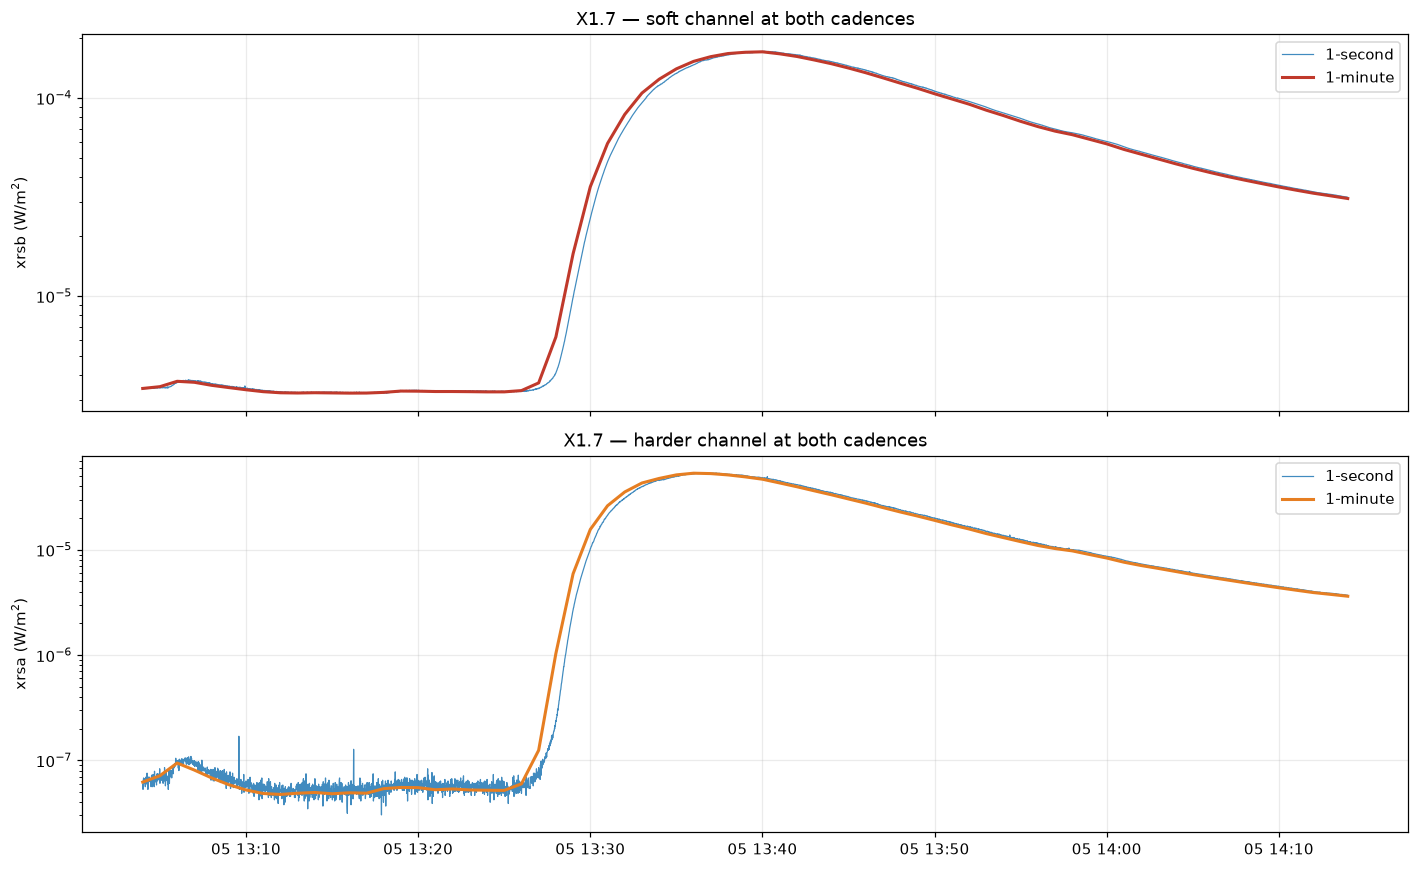

In [5]:
x17 = fl[fl["fl_goescls"] == "X1.7"].iloc[0]
lo = x17["event_starttime"] - pd.Timedelta("20min")
hi = x17["event_endtime"] + pd.Timedelta("20min")

w60 = d60.loc[lo:hi]
w1  = d1.loc[lo:hi]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(w1.index,  w1["xrsb"],  lw=0.8, color=ACC,  label="1-second", alpha=0.9)
axes[0].plot(w60.index, w60["xrsb"], lw=2.0, color=SOFT, label="1-minute")
axes[0].set_yscale("log")
axes[0].set_ylabel("xrsb (W/m$^2$)")
axes[0].set_title("X1.7 — soft channel at both cadences")
axes[0].legend()

axes[1].plot(w1.index,  w1["xrsa"],  lw=0.8, color=ACC,  label="1-second", alpha=0.9)
axes[1].plot(w60.index, w60["xrsa"], lw=2.0, color=HARD, label="1-minute")
axes[1].set_yscale("log")
axes[1].set_ylabel("xrsa (W/m$^2$)")
axes[1].set_title("X1.7 — harder channel at both cadences")
axes[1].legend()

plt.tight_layout()
plt.show()

**What to look for:** does the blue 1-second trace show spikes, wiggles, or
sharp turns that the thick 1-minute line smooths flat? Look especially at the
**rise phase**, between start and peak — that is where the impulsive energy
release happens and where sub-minute structure would appear.

In [6]:
# Peak flux: does 1-minute averaging shave the top off the flare?
p60, p1 = w60["xrsb"].max(), w1["xrsb"].max()
print(f"Peak xrsb, 1-minute : {p60:.3e} W/m^2")
print(f"Peak xrsb, 1-second : {p1:.3e} W/m^2")
print(f"1-minute averaging underestimates the peak by {100*(1-p60/p1):.1f}%")
print()
print(f"Peak time, 1-minute : {w60['xrsb'].idxmax()}")
print(f"Peak time, 1-second : {w1['xrsb'].idxmax()}")

Peak xrsb, 1-minute : 1.709e-04 W/m^2
Peak xrsb, 1-second : 1.719e-04 W/m^2
1-minute averaging underestimates the peak by 0.6%

Peak time, 1-minute : 2024-08-05 13:40:00
Peak time, 1-second : 2024-08-05 13:40:06.082879


## 4. The cadence-aware measurement

Same logic as notebook 02, with one change: `smooth_min` is in **minutes** and
converted to a sample count using the measured cadence. The identical
time-domain operation is applied to both datasets, so any difference in the
result is a real difference, not a filter artefact.

In [7]:
def measure(d, i, smooth_min=3.0, pad_min=30, tol_min=4):
    """Peak times for flare i in dataframe d, or None if the window is unreliable."""
    f = fl.loc[i]
    lo = f["event_starttime"] - pd.Timedelta(minutes=pad_min)
    hi = f["event_endtime"] + pd.Timedelta(minutes=pad_min)
    if i > 0:
        lo = max(lo, fl.loc[i - 1, "event_endtime"])
    if i < len(fl) - 1:
        hi = min(hi, fl.loc[i + 1, "event_starttime"])

    w = d.loc[lo:hi]
    if len(w) < 12:
        return None

    # THE KEY LINE: smoothing defined in TIME, converted to samples
    cad = cadence_s(d)
    win = max(3, int(round(smooth_min * 60 / cad)))

    # interpolate across gaps up to ~1 minute, whatever the cadence
    lim = max(1, int(round(60 / cad)))
    b = w["xrsb"].interpolate(limit=lim)
    a_ = w["xrsa"].interpolate(limit=lim)
    if b.isna().any() or a_.isna().any():
        return None

    db = pd.Series(np.gradient(b.values), index=b.index)
    db = db.rolling(win, center=True, min_periods=1).mean()

    b_pk, a_pk, d_pk = b.idxmax(), a_.idxmax(), db.idxmax()

    off = abs((b_pk - f["event_peaktime"]).total_seconds()) / 60
    if off > tol_min:
        return None

    return {
        "idx": i,
        "letter": f["class_letter"],
        "rise_min": f["rise_min"],
        "lead_deriv": (b_pk - d_pk).total_seconds() / 60,
        "lead_xrsa": (b_pk - a_pk).total_seconds() / 60,
    }


def run(d, label, quiet=False, **kw):
    rows = [r for r in (measure(d, i, **kw) for i in fl.index) if r is not None]
    r = pd.DataFrame(rows)
    if not quiet:
        print(f"{label:>9}: measured {len(r):>3}/{len(fl)}  |  "
              f"median deriv lead {r['lead_deriv'].median():>5.2f} min  |  "
              f"median xrsa lead {r['lead_xrsa'].median():>5.2f} min")
    return r


res60 = run(d60, "1-minute")
res1  = run(d1,  "1-second")

 1-minute: measured  81/95  |  median deriv lead  3.00 min  |  median xrsa lead  1.00 min
 1-second: measured  81/95  |  median deriv lead  2.17 min  |  median xrsa lead  0.73 min


## 5. Side-by-side comparison

In [8]:
cmp = pd.DataFrame({
    "1-minute": [
        len(res60),
        res60["lead_deriv"].median(),
        res60["lead_xrsa"].median(),
        res60[res60["rise_min"] <= 5]["lead_deriv"].median(),
        res60["rise_min"].corr(res60["lead_deriv"]),
    ],
    "1-second": [
        len(res1),
        res1["lead_deriv"].median(),
        res1["lead_xrsa"].median(),
        res1[res1["rise_min"] <= 5]["lead_deriv"].median(),
        res1["rise_min"].corr(res1["lead_deriv"]),
    ],
}, index=["flares measured", "median deriv lead (min)", "median xrsa lead (min)",
          "fast-flare lead (min)", "corr(rise, lead)"])
print(cmp.round(2))

                         1-minute  1-second
flares measured             81.00     81.00
median deriv lead (min)      3.00      2.17
median xrsa lead (min)       1.00      0.73
fast-flare lead (min)        2.00      1.72
corr(rise, lead)             0.59      0.62


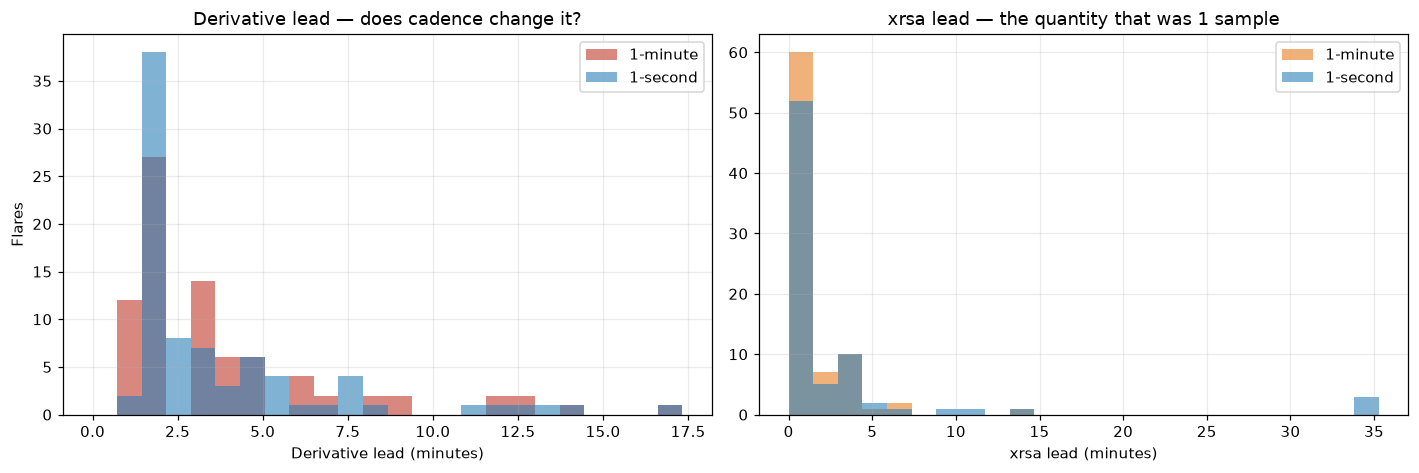

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

bins = np.linspace(0, max(res60["lead_deriv"].max(), res1["lead_deriv"].max()), 25)
axes[0].hist(res60["lead_deriv"], bins=bins, alpha=0.6, color=SOFT, label="1-minute")
axes[0].hist(res1["lead_deriv"],  bins=bins, alpha=0.6, color=ACC,  label="1-second")
axes[0].set_xlabel("Derivative lead (minutes)")
axes[0].set_ylabel("Flares")
axes[0].set_title("Derivative lead — does cadence change it?")
axes[0].legend()

bins2 = np.linspace(0, max(res60["lead_xrsa"].max(), res1["lead_xrsa"].max()), 25)
axes[1].hist(res60["lead_xrsa"], bins=bins2, alpha=0.6, color=HARD, label="1-minute")
axes[1].hist(res1["lead_xrsa"],  bins=bins2, alpha=0.6, color=ACC,  label="1-second")
axes[1].set_xlabel("xrsa lead (minutes)")
axes[1].set_title("xrsa lead — the quantity that was 1 sample")
axes[1].legend()

plt.tight_layout()
plt.show()

The **right-hand panel is the important one.** At 1-minute the `xrsa` lead
was pinned at exactly 1.0 minute because it could not be anything else — the
data had no finer resolution to offer. If the 1-second version spreads into a
real distribution (0.3 min, 0.8 min, 1.4 min...), then that 1.0 was a
quantisation artefact and 1-second is measuring something 1-minute could not.

If it still clusters at whole minutes, the effect is genuinely about a minute
and cadence was not your limitation.

## 6. Robustness at high cadence

One-second data is noisier, so the derivative depends more on the smoothing
width. Check that the 1-second answer is stable the way the 1-minute one was.

In [10]:
print("Median derivative lead vs smoothing width")
print(f"{'smooth':>9} {'1-minute':>10} {'1-second':>10}")
for s in [1, 2, 3, 5, 9]:
    m60 = run(d60, "", quiet=True, smooth_min=s)["lead_deriv"].median()
    m1  = run(d1,  "", quiet=True, smooth_min=s)["lead_deriv"].median()
    print(f"{s:>7} min {m60:>10.2f} {m1:>10.2f}")

print()
print("A column that changes a lot down its length is measuring your filter,")
print("not the Sun. The 1-second column is the one at risk — it is noisier.")

Median derivative lead vs smoothing width
   smooth   1-minute   1-second
      1 min       3.00       2.10
      2 min       3.00       2.37
      3 min       3.00       2.17
      5 min       3.00       2.60
      9 min       5.00       4.50

A column that changes a lot down its length is measuring your filter,
not the Sun. The 1-second column is the one at risk — it is noisier.


## 7. The decision

Fill this in from your output:

| Question | Answer |
|---|---|
| Median derivative lead, 1-min vs 1-sec | ___ vs ___ |
| Median `xrsa` lead, 1-min vs 1-sec | ___ vs ___ |
| Does `xrsa` lead spread into a real distribution at 1-sec? | yes / no |
| Peak flux underestimate from 1-min averaging | ___ % |
| Is the 1-sec result stable across smoothing widths? | yes / no |

**How to decide.**

*Switch to 1-second now* if the leads differ meaningfully, if the `xrsa`
distribution unpins from whole minutes, or if the peak-flux underestimate is
large enough to shift flares across class boundaries — that would corrupt your
classification labels.

*Stay at 1-minute for Steps 5–7* if the numbers agree closely. You would then
have evidence that 1-minute is adequate for the physics, and can move to
1-second in Phase 4 knowing exactly what it buys you.

Either way you now have a measured answer instead of an assumption — and the
comparison itself belongs in your report. Showing you tested a design decision
rather than guessing is worth more than the decision itself.